In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
import os
os.makedirs('images/open_transaction', exist_ok=True)

## linearReg3 — Temporal train / validation / test split

Same OLS specification as `linearReg2`
(`log(Price) ~ log(Land) + log(Area) + Property Type + District + Tenure`),
but instead of fitting on the whole dataset and reading in-sample fit, the data
is split **by transaction year** to measure genuine out-of-sample performance:

| Split | Years | Purpose |
|-------|-------|---------|
| Train | before 2025 (2021–2024) | estimate coefficients |
| Validation | 2025 | check on unseen recent data |
| Test | 2026 | final hold-out, never used for any decision |

Categorical dummies are built on the full dataset first so the three splits
share identical columns; the model is estimated on the training rows only and
then scored on validation and test.

In [2]:
# Load dataset
file_path = '..\processed data\Open Transaction Data Cleaned.xlsx'

# ensure path exists
import os
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Data file not found: {file_path}")
df = pd.read_excel(file_path)

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nRows per year:')
print(df['Year'].value_counts().sort_index())

Dataset loaded successfully.
Shape: 416,627 rows x 13 columns

Rows per year:
Year
2021     49363
2022    118574
2023    118181
2024     89682
2025     35159
2026      5668
Name: count, dtype: int64


In [3]:
# --- Feature engineering (identical spec to linearReg2 final model) ---
cols_ = ['Area', 'Price', 'Land']
for col in cols_:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# log transforms for the two continuous size features
df['log_Land'] = np.where(df['Land'] > 0, np.log(df['Land']), np.nan)
df['log_Area'] = np.where(df['Area'] > 0, np.log(df['Area']), np.nan)

# dummy-encode the categorical predictors on the FULL dataset so every split
# ends up with an identical set of columns
df_dummy = pd.get_dummies(df,
                          columns=['Property Type', 'District', 'Tenure'],
                          drop_first=True,
                          dtype=int)

features = ['log_Land', 'log_Area'] + [
    col for col in df_dummy.columns
    if ('Property Type' in col or 'District' in col or 'Tenure' in col)
]

# target on log scale (percentage effects, less skew)
df_dummy['log_Price'] = np.where(df_dummy['Price'] > 0,
                                 np.log(df_dummy['Price']), np.nan)

# drop rows with missing target or features
df_model = df_dummy.dropna(subset=['log_Price'] + features).copy()
print(f'Rows available for modelling: {len(df_model):,}')
print(f'Number of predictors: {len(features)}')

Rows available for modelling: 308,865
Number of predictors: 139


In [4]:
# --- Temporal split by transaction year ---
train_df = df_model[df_model['Year'] < 2025]
val_df   = df_model[df_model['Year'] == 2025]
test_df  = df_model[df_model['Year'] == 2026]

print(f'Train (<2025):   {len(train_df):,} rows')
print(f'Validation 2025: {len(val_df):,} rows')
print(f'Test 2026:       {len(test_df):,} rows')

# keep only predictors that actually vary within the TRAINING set
# (a dummy that is constant in train carries no information and makes X singular)
keep_features = [c for c in features if train_df[c].nunique() > 1]
dropped = [c for c in features if c not in keep_features]
print(f'\nPredictors kept: {len(keep_features)}  |  dropped (constant in train): {len(dropped)}')
if dropped:
    print('Dropped:', dropped)

def make_Xy(frame):
    X = sm.add_constant(frame[keep_features], has_constant='add')
    y = frame['log_Price']
    return X, y

X_train, y_train = make_Xy(train_df)
X_val,   y_val   = make_Xy(val_df)
X_test,  y_test  = make_Xy(test_df)

Train (<2025):   277,332 rows
Validation 2025: 27,145 rows
Test 2026:       4,388 rows

Predictors kept: 133  |  dropped (constant in train): 6
Dropped: ['Property Type_Condominium/Apartment', 'Property Type_Flat', 'Property Type_Low-Cost Flat', 'Property Type_Town House', 'District_Bahagian Sarikie', 'District_DAERAH KECIL MUADZAM SHAH']


In [5]:
# --- Fit OLS on the training set only ---
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_Price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     8616.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:51:41   Log-Likelihood:                -57000.
No. Observations:              277332   AIC:                         1.143e+05
Df Residuals:                  277198   BIC:                         1.157e+05
Df Model:                         133                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [6]:
# --- Out-of-sample evaluation helper ---
def eval_split(name, fitted, X, y_log, price):
    pred_log = fitted.predict(X)
    resid = y_log - pred_log
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y_log - y_log.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    rmse_log = np.sqrt(np.mean(resid ** 2))
    mae_log = np.mean(np.abs(resid))
    # back-transform to RM (naive exp; retransformation bias noted below)
    pred_price = np.exp(pred_log)
    ape = np.abs(pred_price - price) / price
    return {
        'split': name, 'n': len(y_log),
        'R2': r2, 'RMSE_log': rmse_log, 'MAE_log': mae_log,
        'MAE_RM': np.mean(np.abs(pred_price - price)),
        'MedAPE_%': np.median(ape) * 100,
        'MAPE_%': np.mean(ape) * 100,
    }

rows = [
    eval_split('Train (<2025)', model, X_train, y_train, train_df['Price']),
    eval_split('Val 2025',      model, X_val,   y_val,   val_df['Price']),
    eval_split('Test 2026',     model, X_test,  y_test,  test_df['Price']),
]
metrics = pd.DataFrame(rows).set_index('split')
print(metrics.round(4).to_string())

print('\nObservation:')
print('  - R2 / RMSE on the log scale measure fit on unseen years.')
print('  - MedAPE (median absolute % error) is the most robust price-scale metric.')
print('  - exp(pred) is a naive back-transform and slightly under-predicts the mean;')
print('    a smearing factor mean(exp(train residuals)) can be applied for unbiased RM.')

                    n      R2  RMSE_log  MAE_log       MAE_RM  MedAPE_%   MAPE_%
split                                                                           
Train (<2025)  277332  0.8052    0.2972   0.2098  117267.0807   15.6564  23.5734
Val 2025        27145  0.7620    0.3151   0.2289  125026.4892   17.0127  24.2920
Test 2026        4388  0.7555    0.3235   0.2369  127219.9373   18.0993  25.1423

Observation:
  - R2 / RMSE on the log scale measure fit on unseen years.
  - MedAPE (median absolute % error) is the most robust price-scale metric.
  - exp(pred) is a naive back-transform and slightly under-predicts the mean;
    a smearing factor mean(exp(train residuals)) can be applied for unbiased RM.


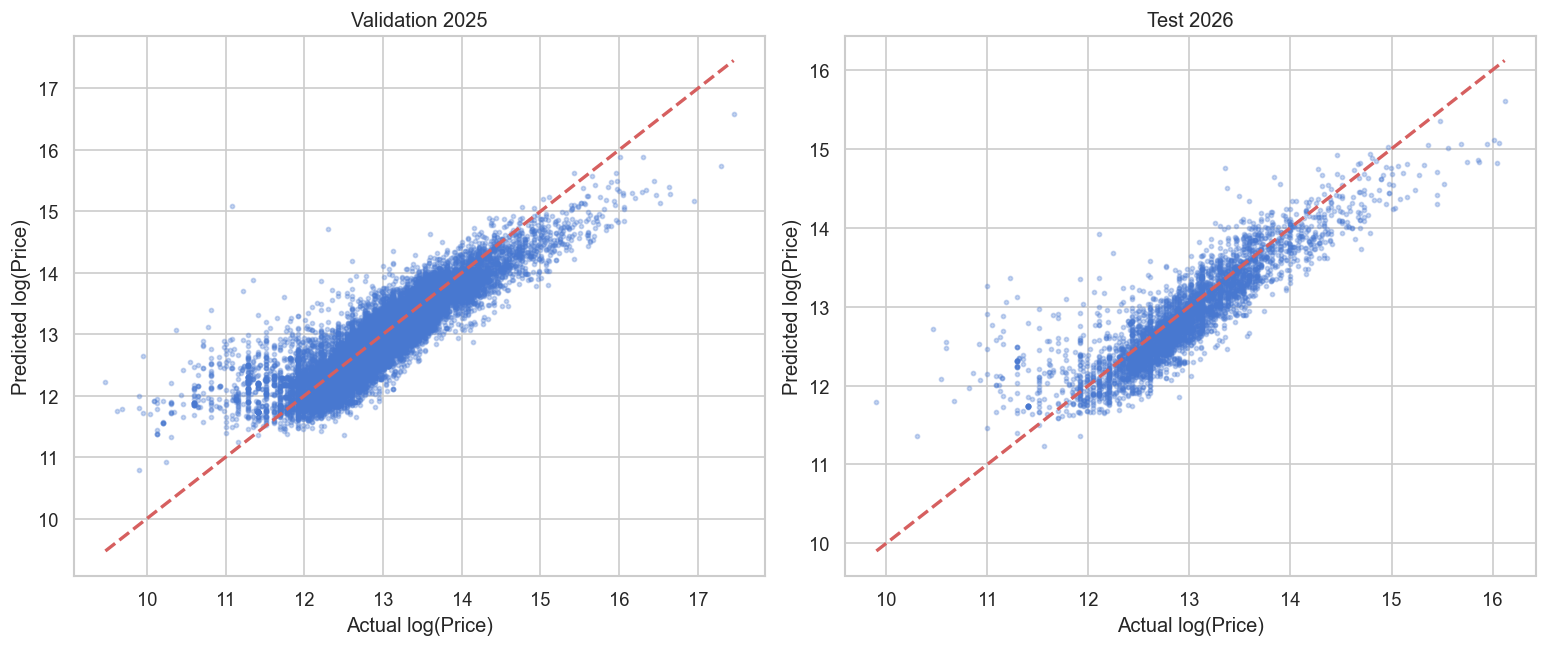

In [7]:
# --- Predicted vs actual (log price) on validation & test ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, frame, X, y_log, title in [
    (axes[0], val_df,  X_val,  y_val,  'Validation 2025'),
    (axes[1], test_df, X_test, y_test, 'Test 2026'),
]:
    pred = model.predict(X)
    ax.scatter(y_log, pred, s=6, alpha=0.3)
    lo, hi = float(y_log.min()), float(y_log.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2)
    ax.set_xlabel('Actual log(Price)')
    ax.set_ylabel('Predicted log(Price)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [8]:
# --- VIF on the training design matrix ---
vif_data = pd.DataFrame({'Variable': X_train.columns})
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]
vif_results = vif_data.sort_values('VIF', ascending=False)
print(vif_results.to_string(index=False))

high_vif = vif_results[(vif_results['VIF'] > 5) & (vif_results['Variable'] != 'const')]
print(f'\n{len(high_vif)} predictor(s) with VIF > 5 (const excluded).')

                                    Variable        VIF
                                       const 497.736241
                        District_Johor Bahru   8.461858
     Property Type_2 - 2 1/2 Storey Terraced   6.676568
     Property Type_1 - 1 1/2 Storey Terraced   4.968785
                           District_Petaling   4.813990
                              District_Kinta   4.774125
                           District_Seremban   4.440702
                              District_Klang   4.233489
                        District_Hulu Langat   3.772138
                         District_Kuala Muda   3.427853
                            District_Kuantan   3.291980
                                    log_Area   3.143515
                Property Type_Low-Cost House   3.136223
                      District_Melaka Tengah   2.915810
                                    log_Land   2.882506
                             District_Gombak   2.840286
                            District_Manjung   2

In [9]:
# --- Remove extreme TRAINING outliers (+/-3 SD of residuals), refit, re-score ---
resid_train = model.resid
z = (resid_train - resid_train.mean()) / resid_train.std()
train_clean = train_df[np.abs(z) < 3].copy()
print(f'Training rows removed as outliers: {len(train_df) - len(train_clean):,}')

Xc_train, yc_train = make_Xy(train_clean)
model_final = sm.OLS(yc_train, Xc_train).fit()
robust_results = model_final.get_robustcov_results(cov_type='HAC', maxlags=1)
print(robust_results.summary())

# re-evaluate the cleaned-train model on val & test (hold-outs left intact)
rows2 = [
    eval_split('Train* (clean)', model_final, Xc_train, yc_train, train_clean['Price']),
    eval_split('Val 2025',       model_final, X_val,   y_val,   val_df['Price']),
    eval_split('Test 2026',      model_final, X_test,  y_test,  test_df['Price']),
]
print('\nAfter outlier-cleaning the training set:')
print(pd.DataFrame(rows2).set_index('split').round(4).to_string())
print('\nNote: outliers are removed from TRAIN only - validation and test stay intact,')
print('so the hold-out metrics remain an honest estimate of real-world error.')

Training rows removed as outliers: 4,031
                            OLS Regression Results                            
Dep. Variable:              log_Price   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     5757.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:55:06   Log-Likelihood:                -7960.1
No. Observations:              273301   AIC:                         1.619e+04
Df Residuals:                  273167   BIC:                         1.760e+04
Df Model:                         133                                         
Covariance Type:                  HAC                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

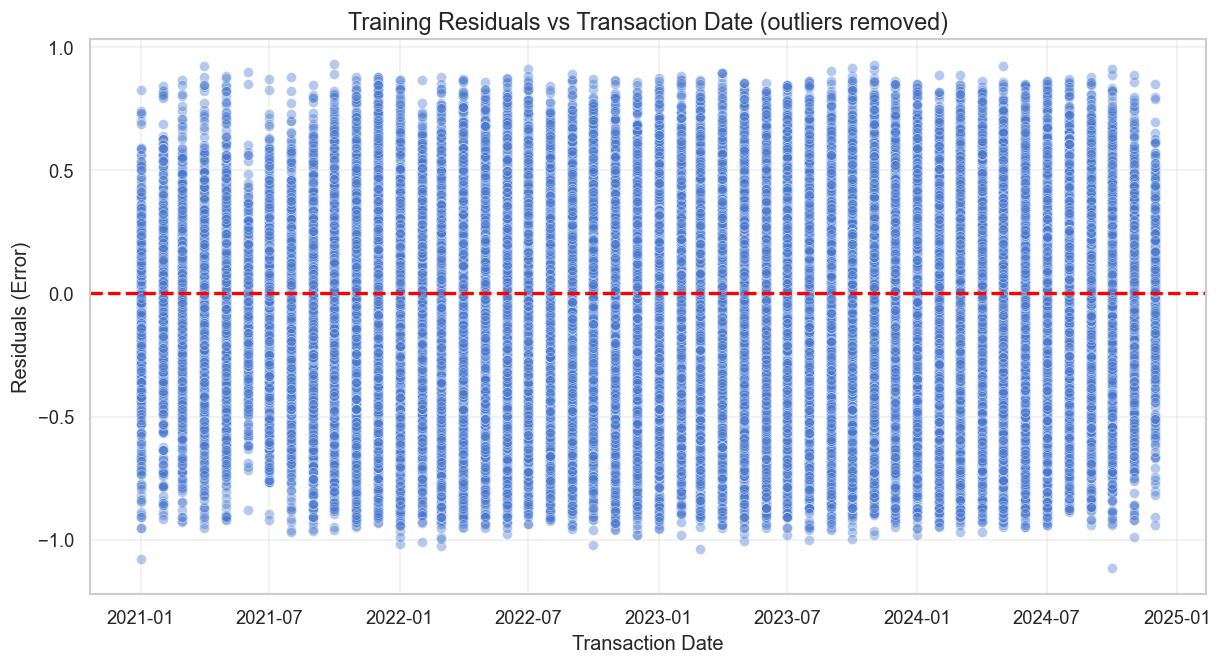

In [10]:
# --- Training residuals vs date after outlier removal ---
resid_final = model_final.resid
plot_data = pd.DataFrame({
    'Transaction Date': train_clean['Transaction Date'],
    'Residuals': resid_final,
})
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data, x='Transaction Date', y='Residuals', alpha=0.4)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Training Residuals vs Transaction Date (outliers removed)', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# --- Residual diagnostics on the final training model ---
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(resid_final)
print(f'Durbin-Watson statistic: {dw_stat:.3f} (values around 2 suggest no serial correlation)')

bp_test = het_breuschpagan(resid_final, Xc_train)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test
print('\nBreusch-Pagan test (training set):')
print(f'  LM statistic = {lm_stat:.3f}, p-value = {lm_pvalue:.3f}')
print(f'  F statistic  = {f_stat:.3f}, p-value = {f_pvalue:.3f}')

print('\nObservation: same diagnostics as linearReg2 but computed on the temporal')
print('training split; the HAC robust standard errors above guard inference against')
print('the heteroskedasticity / serial correlation these tests flag.')

Durbin-Watson statistic: 0.742 (values around 2 suggest no serial correlation)

Breusch-Pagan test (training set):
  LM statistic = 22012.325, p-value = 0.000
  F statistic  = 179.916, p-value = 0.000

Observation: same diagnostics as linearReg2 but computed on the temporal
training split; the HAC robust standard errors above guard inference against
the heteroskedasticity / serial correlation these tests flag.
